In [32]:
from pathlib import Path

# OR if in a notebook:
BASE_DIR = Path.cwd().parent.parent.parent

DATA_RAW = BASE_DIR / "data" / "raw"
DATA_PROCESSED = BASE_DIR / "data" / "processed"

print("BASE_DIR:", BASE_DIR)
print("DATA_RAW exists:", DATA_RAW.exists())
print("DATA_PROCESSED exists:", DATA_PROCESSED.exists())

BASE_DIR: /files
DATA_RAW exists: False
DATA_PROCESSED exists: False


In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PROCESSED = BASE_DIR / "data" / "processed"

# Load the events with AR and CAR already computed.
# Be resilient if the file is missing: try to locate it under BASE_DIR,
# otherwise create an empty DataFrame with expected columns so downstream cells don't error.
candidate = DATA_PROCESSED / "events_labeled.csv"

if candidate.exists():
	events = pd.read_csv(candidate, sep=";")
else:
	# search for any file named events_with_car.* under BASE_DIR
	matches = list(BASE_DIR.rglob("events_labeled.*"))
	if matches:
		filepath = matches[0]
		print(f"Found file at: {filepath}")
		if filepath.suffix.lower() == ".csv":
			# attempt to read CSV (assume ';' delimiter like original)
			events = pd.read_csv(filepath, sep=";")
		elif filepath.suffix.lower() == ".parquet":
			events = pd.read_parquet(filepath)
		elif filepath.suffix.lower() == ".feather":
			events = pd.read_feather(filepath)
		else:
			# fallback to pandas read_csv
			events = pd.read_csv(filepath, sep=";")
	else:
		print(f"Warning: '{candidate}' not found and no match under BASE_DIR ({BASE_DIR}).")
		if DATA_PROCESSED.exists():
			print("Contents of DATA_PROCESSED:", [p.name for p in DATA_PROCESSED.iterdir()])
		else:
			print("DATA_PROCESSED directory does not exist:", DATA_PROCESSED)
		# create empty DataFrame with expected columns to avoid errors in downstream cells
		cols = ["event_id", "event_type", "event_date", "trading_date", "ticker", "AR_event", "CAR_m1_p1", "is_rockstar"]
		events = pd.DataFrame(columns=cols)
		print("Created empty 'events' DataFrame with columns:", cols)

# convert date columns safely if present
for col in ["event_date", "trading_date"]:
	if col in events.columns:
		events[col] = pd.to_datetime(events[col], errors="coerce")

events.head()

Found file at: /files/capstone_project/game-market-event-analyzer/data/processed/events_labeled.csv


,event_id,date,publisher,ticker,studio,is_rockstar,game,franchise,event_type,sentiment,...,market_return,trading_date,AR_event,CAR_m1_p1,CAR_0_1,CAR_0_3,CAR_0_5,impact_label,impact_label_num,impact_high
0,TTWO_2011_GTA5_ANNOUNCEMENT,2011-10-25,Take-Two,TTWO,Rockstar Games,1,GTA V,GTA,Major Announcement,positive,...,-0.020045,2011-10-25,0.075962,0.077457,0.068804,0.095792,0.095792,High,2,1
1,GTAV_2011_TRAILER1,2011-11-02,Take-Two,TTWO,Rockstar,1,GTA V,GTA,Trailer/Reveal,positive,...,0.016105,2011-11-02,0.007217,0.000302,0.005652,0.011005,-0.016210,Low,0,0
2,GTAV_2012_SCREENSHOTS,2012-07-12,Take-Two,TTWO,Rockstar,1,GTA V,GTA,Trailer/Reveal,neutral,...,-0.004987,2012-07-12,-0.002412,-0.037677,-0.041531,-0.041531,-0.033895,High,2,1
3,GTAV_2012_TRAILER2,2012-11-14,Take-Two,TTWO,Rockstar,1,GTA V,GTA,Trailer/Reveal,positive,...,-0.013852,2012-11-14,0.008991,0.025354,0.016916,0.037798,0.060788,Medium,1,0
4,GTAV_2013_DELAY,2013-01-31,Take-Two,TTWO,Rockstar,1,GTA V,GTA,Delay,negative,...,-0.002563,2013-01-31,-0.066285,-0.023034,-0.026151,-0.026151,-0.035325,Medium,1,0


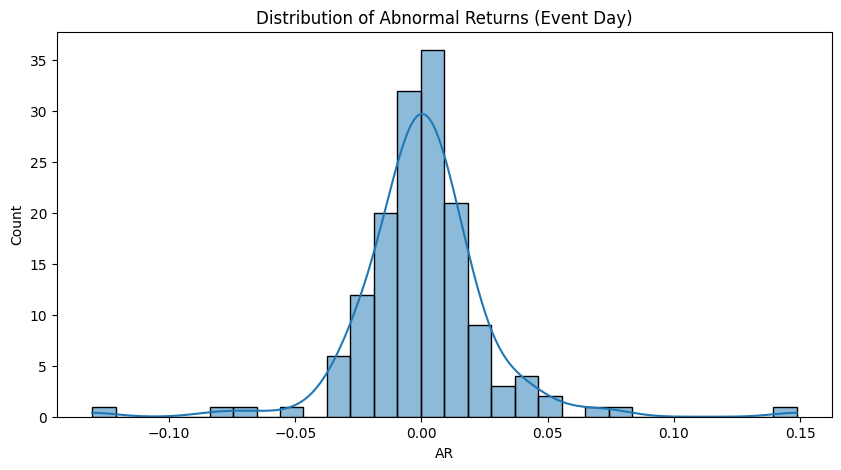

In [34]:
plt.figure(figsize=(10,5))
sns.histplot(events["AR_event"].dropna(), bins=30, kde=True)
plt.title("Distribution of Abnormal Returns (Event Day)")
plt.xlabel("AR")
plt.ylabel("Count")
plt.show()

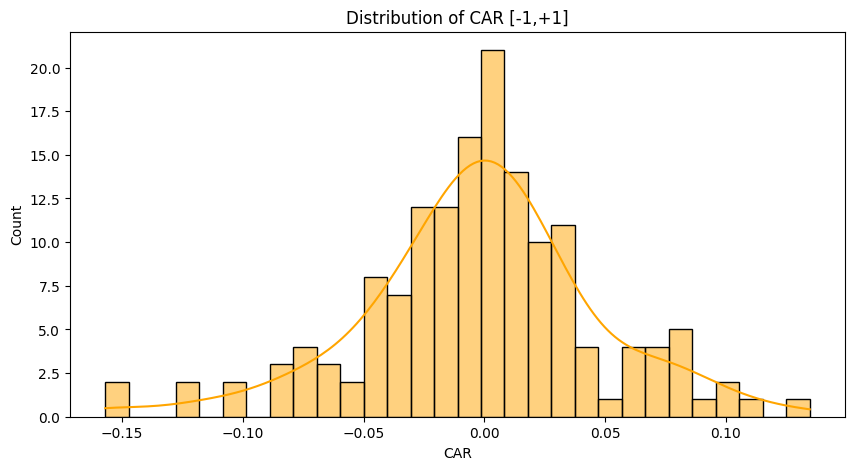

In [35]:
plt.figure(figsize=(10,5))
sns.histplot(events["CAR_m1_p1"].dropna(), bins=30, kde=True, color='orange')
plt.title("Distribution of CAR [-1,+1]")
plt.xlabel("CAR")
plt.ylabel("Count")
plt.show()

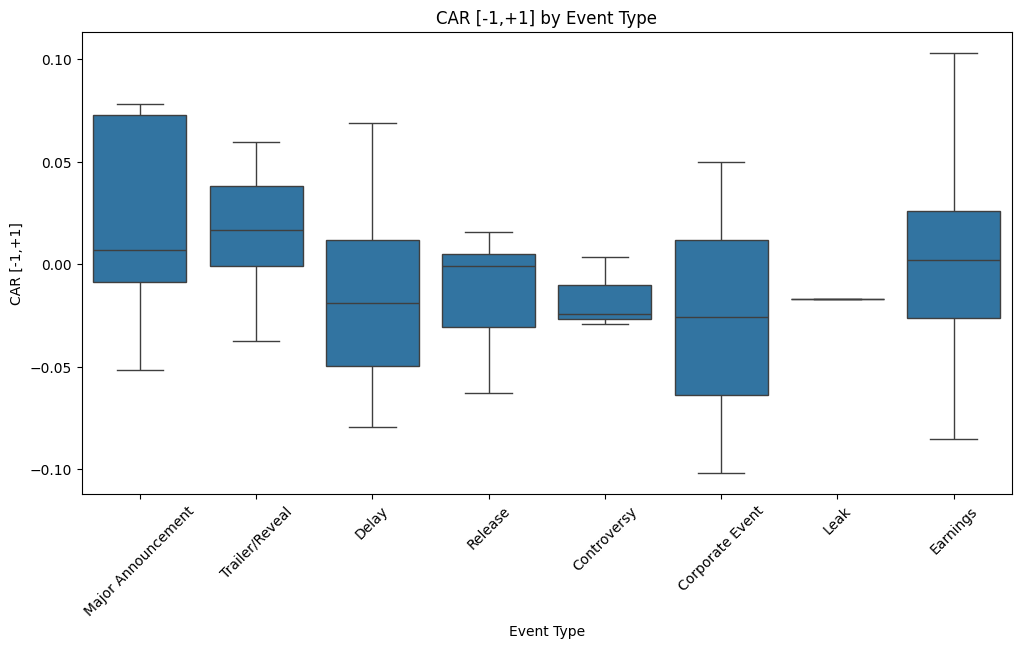

In [36]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=events,
    x="event_type",
    y="CAR_m1_p1",
    showfliers=False  # optional, remove extreme outliers
)
plt.xticks(rotation=45)
plt.title("CAR [-1,+1] by Event Type")
plt.ylabel("CAR [-1,+1]")
plt.xlabel("Event Type")
plt.show()

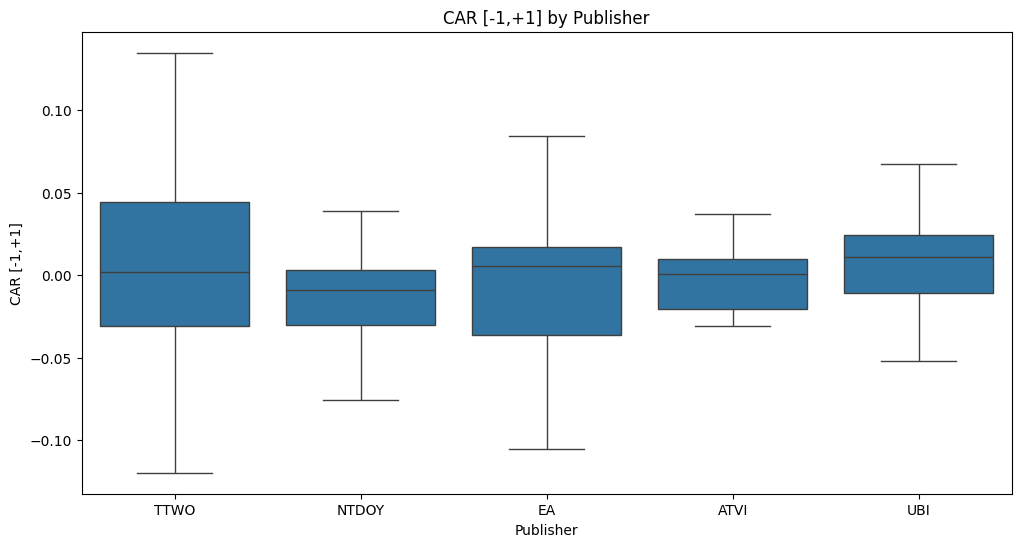

In [37]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=events,
    x="ticker",
    y="CAR_m1_p1",
    showfliers=False
)
plt.title("CAR [-1,+1] by Publisher")
plt.ylabel("CAR [-1,+1]")
plt.xlabel("Publisher")
plt.show()

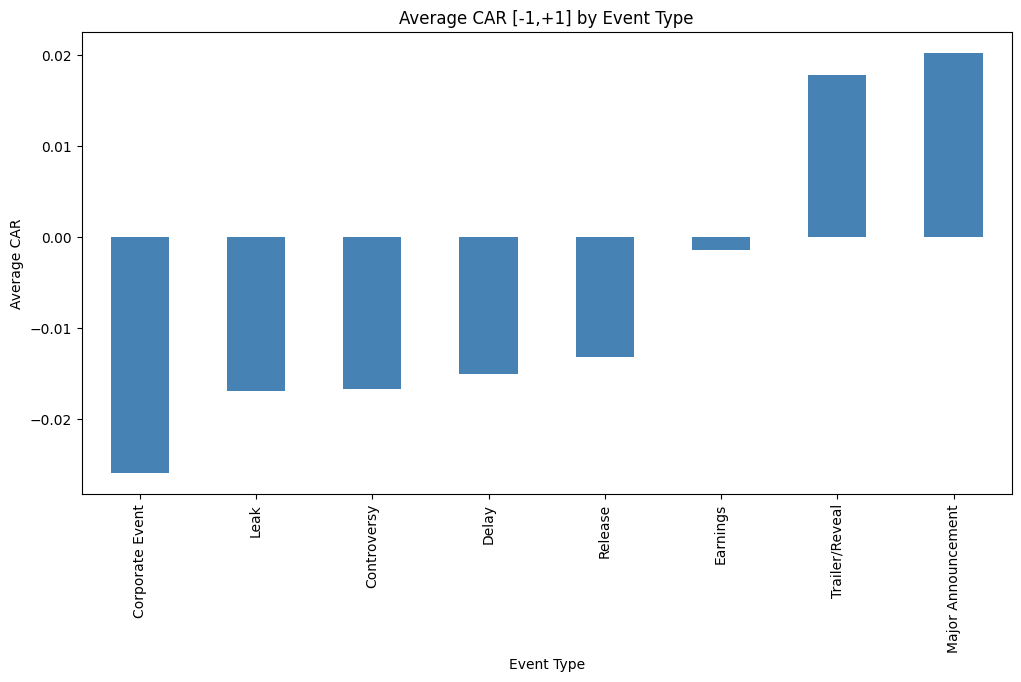

In [38]:
car_means = events.groupby("event_type")["CAR_m1_p1"].mean().sort_values()

plt.figure(figsize=(12,6))
car_means.plot(kind="bar", color="steelblue")
plt.title("Average CAR [-1,+1] by Event Type")
plt.ylabel("Average CAR")
plt.xlabel("Event Type")
plt.show()

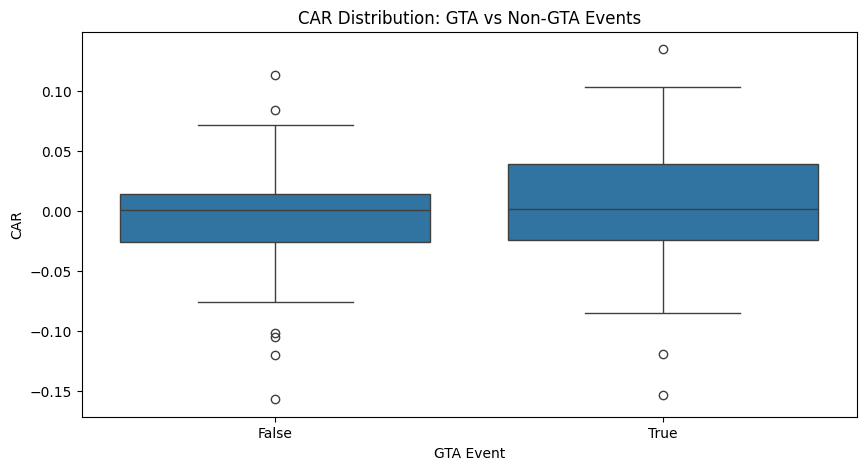

In [39]:
events["is_gta"] = events["is_rockstar"].str.contains("1", case=False, na=False)

plt.figure(figsize=(10,5))
sns.boxplot(data=events, x="is_gta", y="CAR_m1_p1")
plt.title("CAR Distribution: GTA vs Non-GTA Events")
plt.xlabel("GTA Event")
plt.ylabel("CAR")
plt.show()